<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%203/L09_Activation_Functions_In_Depth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=mFIYldBMyEQ) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%203/NPTEL_Jul24_DL4CV_W03_P05.pdf)

In [1]:
# Week 3, Lecture 9: Improving Training of NN Part 1
from IPython.display import HTML, display

VIDEO_ID = "mFIYldBMyEQ"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 3, Lecture 9: Activation Functions In Depth

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§3.5 Improvements in Training of Neural Networks**.

We build the common activations from scratch, then use tiny PyTorch experiments to
actually *see* why the choice of activation can make or break training.

**What you will learn**
- The properties a good activation should have: continuous, differentiable, non-decreasing, cheap to compute.
- **Sigmoid, tanh, ReLU, Leaky ReLU, ELU** coded from scratch (with their derivatives), verified against PyTorch.
- **Saturation:** why sigmoid and tanh gradients collapse to almost $0$ away from the origin.
- **Vanishing gradients across depth (the central demo):** per-layer gradient norms in a deep stack, sigmoid vs ReLU.
- **The Dying ReLU problem:** how units go permanently silent, and how Leaky ReLU / ELU revive them.
- **The zero-centered issue:** why all-positive activations force zig-zag weight updates.
- A practical "which activation should I use" summary.

**How to run**  Works on Colab (CPU or GPU) or a local Jupyter install. Every
experiment here is tiny (single forward/backward passes on small tensors) and
finishes in seconds on CPU. Run the setup cell below first, then go top to bottom.

**Contents**

1. The activation zoo, from scratch
2. Saturation, quantitatively
3. Vanishing gradients across depth (the central demo)
4. The Dying ReLU problem
5. The zero-centered issue (brief)

## Review

The previous lecture built early stopping, data augmentation, noise injection, ensembles and dropout, all of which control *how* a network fits its data. This lecture returns to a single component, the activation function, and shows how that choice alone can stop a deep network training at all.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and local Jupyter.
import sys, subprocess
# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, FloatSlider, IntSlider, Dropdown, Checkbox, fixed
%matplotlib inline

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Use a GPU if one is available, otherwise CPU. Every demo here is tiny and
# runs in seconds on CPU, so no GPU is required.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.8.0 | device: cpu


## 1. The activation zoo, from scratch

An activation is a **non-linear function applied to the output of a neuron**. The
slides ask what properties it should have. A good activation is:

- **continuous** and **differentiable** (so we can backpropagate through it),
- **non-decreasing**, and
- **easy to compute**.

We work in three steps:

1. Implement each activation and its derivative directly from the math (no torch builtins).
2. Verify our from-scratch versions match PyTorch's builtins and its autograd engine.
3. Plot every function next to its derivative.

Definitions from the slides:

- **Sigmoid:** $\sigma(x) = \dfrac{1}{1+e^{-x}}$, with $\sigma'(x) = \sigma(x)\,\big(1-\sigma(x)\big)$. Squashes any input into $(0, 1)$.
- **Tanh:** $\tanh(x) = \dfrac{e^{x}-e^{-x}}{e^{x}+e^{-x}}$, with $\tanh'(x) = 1-\tanh^2(x)$. Squashes into $(-1, 1)$.
- **ReLU:** $\mathrm{ReLU}(x) = \max(0, x)$, with derivative $0$ for $x<0$ and $1$ for $x>0$.
- **Leaky ReLU:** $\max(\alpha x,\, x)$, a small slope $\alpha$ for $x<0$.
- **ELU:** $x$ for $x>0$, else $\alpha\,(e^{x}-1)$.

In [3]:
# Step 1: implement each activation and its analytic derivative directly from
# the slide math, using plain torch tensor ops (NOT the torch builtins).

def sigmoid(x):
    # sigma(x) = 1 / (1 + e^-x)
    return 1.0 / (1.0 + torch.exp(-x))

def d_sigmoid(x):
    # d sigma / dx = sigma(x) * (1 - sigma(x))
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh(x):
    # tanh(x) = (e^x - e^-x) / (e^x + e^-x)
    ex, emx = torch.exp(x), torch.exp(-x)
    return (ex - emx) / (ex + emx)

def d_tanh(x):
    # d tanh / dx = 1 - tanh(x)^2
    t = tanh(x)
    return 1.0 - t * t

def relu(x):
    # ReLU(x) = max(0, x)
    return torch.clamp(x, min=0.0)

def d_relu(x):
    # derivative: 1 for x > 0, else 0 (we take 0 at the non-differentiable point)
    return (x > 0).to(x.dtype)

def leaky_relu(x, alpha=0.01):
    # Leaky ReLU keeps a small slope alpha for x < 0: max(alpha*x, x)
    return torch.where(x > 0, x, alpha * x)

def d_leaky_relu(x, alpha=0.01):
    # derivative: 1 for x > 0, else alpha
    return torch.where(x > 0, torch.ones_like(x), alpha * torch.ones_like(x))

def elu(x, alpha=1.0):
    # ELU(x) = x for x > 0, else alpha*(e^x - 1)
    return torch.where(x > 0, x, alpha * (torch.exp(x) - 1.0))

def d_elu(x, alpha=1.0):
    # derivative: 1 for x > 0, else alpha*e^x
    return torch.where(x > 0, torch.ones_like(x), alpha * torch.exp(x))

print("Defined from scratch: sigmoid, tanh, relu, leaky_relu, elu (and their derivatives).")

Defined from scratch: sigmoid, tanh, relu, leaky_relu, elu (and their derivatives).


In [4]:
# Step 2: verify our from-scratch versions agree with PyTorch. We check the
# FUNCTION values against torch builtins, and the DERIVATIVES against autograd
# (we let torch differentiate its own builtin and compare with our formula).
xv = torch.linspace(-6, 6, 200)

pairs = {
    "sigmoid": (sigmoid(xv),        torch.sigmoid(xv)),
    "tanh":    (tanh(xv),           torch.tanh(xv)),
    "relu":    (relu(xv),           torch.relu(xv)),
    "leaky":   (leaky_relu(xv, 0.1), F.leaky_relu(xv, 0.1)),
    "elu":     (elu(xv, 1.0),        F.elu(xv, 1.0)),
}
print("max |ours - torch| for the FUNCTION values:")
for name, (a, b) in pairs.items():
    print("  %-8s : %.2e" % (name, (a - b).abs().max().item()))

def autograd_deriv(fn, x):
    """Gradient of fn at each point via autograd (torch differentiates itself)."""
    x = x.clone().detach().requires_grad_(True)
    g, = torch.autograd.grad(fn(x).sum(), x)
    return g

print("\nmax |our derivative - autograd| for the DERIVATIVES:")
print("  sigmoid  : %.2e" % (d_sigmoid(xv) - autograd_deriv(torch.sigmoid, xv)).abs().max().item())
print("  tanh     : %.2e" % (d_tanh(xv)    - autograd_deriv(torch.tanh, xv)).abs().max().item())
print("  relu     : %.2e" % (d_relu(xv)    - autograd_deriv(torch.relu, xv)).abs().max().item())
print("  leaky    : %.2e" % (d_leaky_relu(xv, 0.1) - autograd_deriv(lambda t: F.leaky_relu(t, 0.1), xv)).abs().max().item())
print("  elu      : %.2e" % (d_elu(xv, 1.0) - autograd_deriv(lambda t: F.elu(t, 1.0), xv)).abs().max().item())

max |ours - torch| for the FUNCTION values:
  sigmoid  : 0.00e+00
  tanh     : 1.19e-07
  relu     : 0.00e+00
  leaky    : 0.00e+00
  elu      : 5.96e-08

max |our derivative - autograd| for the DERIVATIVES:
  sigmoid  : 0.00e+00
  tanh     : 2.38e-07
  relu     : 0.00e+00
  leaky    : 0.00e+00
  elu      : 0.00e+00


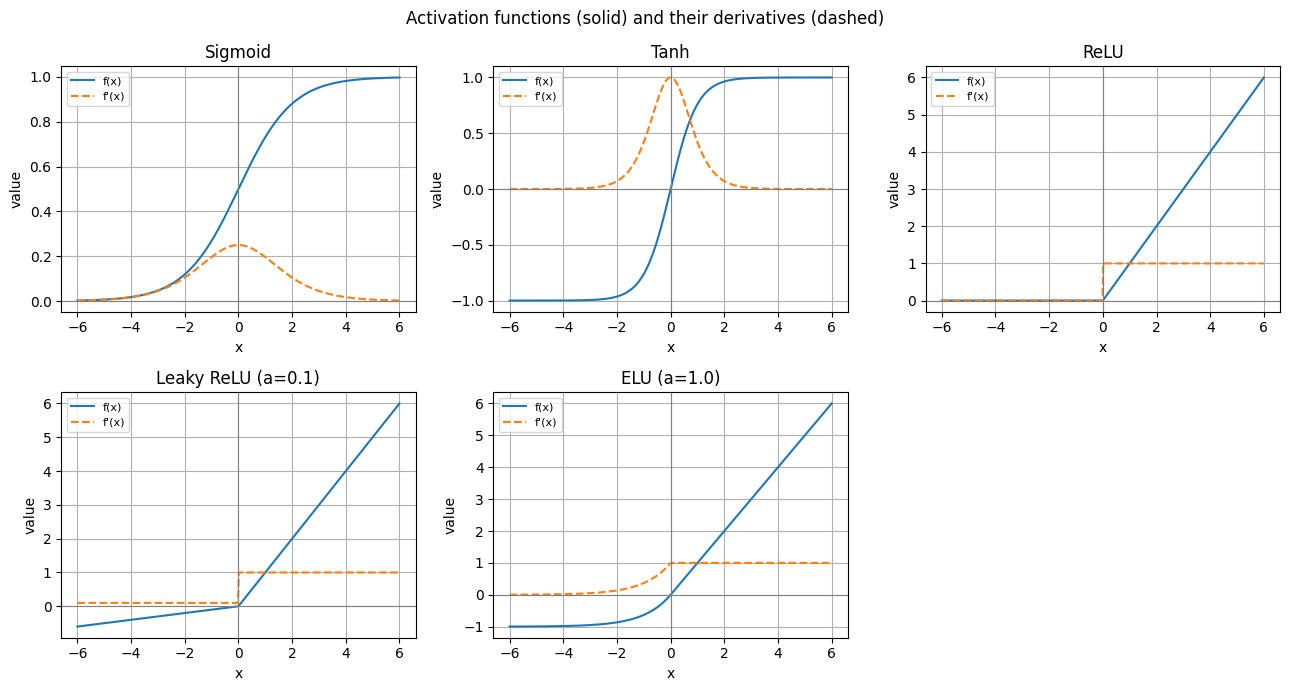

In [5]:
# Step 3: plot each activation (solid) next to its derivative (dashed).
grid = torch.linspace(-6, 6, 400)
gx = grid.numpy()
zoo = [
    ("Sigmoid",            sigmoid(grid),          d_sigmoid(grid)),
    ("Tanh",               tanh(grid),             d_tanh(grid)),
    ("ReLU",               relu(grid),             d_relu(grid)),
    ("Leaky ReLU (a=0.1)", leaky_relu(grid, 0.1),  d_leaky_relu(grid, 0.1)),
    ("ELU (a=1.0)",        elu(grid, 1.0),         d_elu(grid, 1.0)),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, f, d) in zip(axes.ravel(), zoo):
    ax.plot(gx, f.numpy(), label="f(x)")
    ax.plot(gx, d.numpy(), "--", label="f'(x)")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(name)
    ax.set_xlabel("x"); ax.set_ylabel("value")
    ax.legend(loc="upper left", fontsize=8)
axes.ravel()[-1].axis("off")   # 6th slot is unused
fig.suptitle("Activation functions (solid) and their derivatives (dashed)")
plt.tight_layout()
plt.show()

### Widget: explore each activation and its saturation region

Pick an activation and move the parameter slider:

- For **sigmoid / tanh** the slider is a **gain** $a$ (we plot $f(a\,x)$). A larger
  gain makes the curve steeper and pushes it into saturation sooner.
- For **Leaky ReLU** the slider is the negative slope $\alpha$ (note $\alpha=0$
  recovers plain ReLU).
- For **ELU** the slider is $\alpha$.
- **ReLU** has no parameter, so the slider is ignored.

The red band marks where $|f'(x)| < 0.1$: the **saturation region**, where the
gradient is nearly zero and learning almost stops.

In [6]:
# WIDGET 1: dropdown activation + parameter slider -> redraw f and f' and shade
# the saturation region (|f'| < 0.1). All computation happens inside the callback.
def explore_activation(name="sigmoid", param=1.0):
    x = torch.linspace(-8, 8, 500)
    if name == "sigmoid":
        f, d, note = sigmoid(param * x), param * d_sigmoid(param * x), "gain a=%.2f" % param
    elif name == "tanh":
        f, d, note = tanh(param * x), param * d_tanh(param * x), "gain a=%.2f" % param
    elif name == "relu":
        f, d, note = relu(x), d_relu(x), "no parameter"
    elif name == "leaky_relu":
        f, d, note = leaky_relu(x, param), d_leaky_relu(x, param), "neg slope a=%.2f" % param
    else:  # elu
        f, d, note = elu(x, param), d_elu(x, param), "alpha=%.2f" % param
    gx = x.numpy(); fn = f.numpy(); dn = d.numpy()
    sat = np.abs(dn) < 0.1

    plt.figure()
    plt.plot(gx, fn, label="f(x)")
    plt.plot(gx, dn, "--", label="f'(x)")
    plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
    y0, y1 = plt.ylim()
    plt.fill_between(gx, y0, y1, where=sat, color="red", alpha=0.15,
                     label="saturation |f'| < 0.1")
    plt.ylim(y0, y1)
    plt.title("%s (%s): function, derivative, saturation region" % (name, note))
    plt.xlabel("x"); plt.ylabel("value"); plt.legend(loc="upper left", fontsize=8)
    plt.show()

interact(explore_activation,
         name=Dropdown(options=["sigmoid", "tanh", "relu", "leaky_relu", "elu"], value="sigmoid"),
         param=FloatSlider(min=0.0, max=3.0, step=0.05, value=1.0));

interactive(children=(Dropdown(description='name', options=('sigmoid', 'tanh', 'relu', 'leaky_relu', 'elu'), v…

## 2. Saturation, quantitatively

"Saturation" means the function flattens out, so its derivative goes to (almost)
zero. Since a weight update is proportional to the gradient, a **saturated neuron
barely learns**: the slide notes that the gradient of a sigmoid neuron at
saturation is very small, which makes training slow.

- **Sigmoid's** derivative peaks at only $0.25$ (at $x=0$) and decays to $\approx 0$ for $|x| \gtrsim 5$.
- **Tanh's** derivative peaks at $1.0$ (at $x=0$) but also decays to $\approx 0$ in the tails.
- **ReLU's** derivative is a flat $1$ for every positive input: no saturation on the positive side.

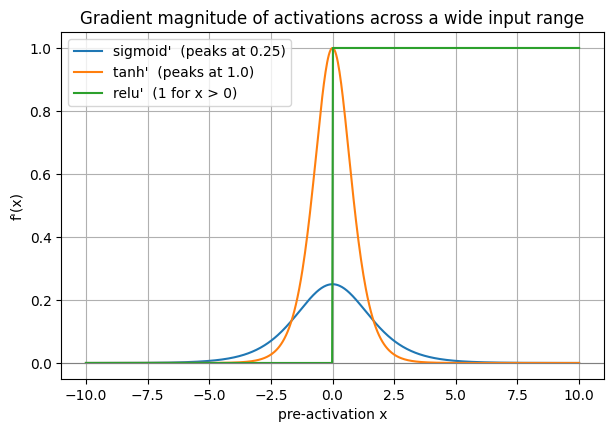

How the derivative shrinks as we move away from the origin:
  |x|=0 :  sigmoid'=0.2500   tanh'=1.0000   relu'=0
  |x|=1 :  sigmoid'=0.1966   tanh'=0.4200   relu'=1
  |x|=3 :  sigmoid'=0.0452   tanh'=0.0099   relu'=1
  |x|=5 :  sigmoid'=0.0066   tanh'=0.0002   relu'=1
  |x|=8 :  sigmoid'=0.0003   tanh'=0.0000   relu'=1


In [7]:
# Plot the gradient magnitude of each activation across a wide input range.
x = torch.linspace(-10, 10, 600)
gx = x.numpy()
plt.figure()
plt.plot(gx, d_sigmoid(x).numpy(), label="sigmoid'  (peaks at 0.25)")
plt.plot(gx, d_tanh(x).numpy(),    label="tanh'  (peaks at 1.0)")
plt.plot(gx, d_relu(x).numpy(),    label="relu'  (1 for x > 0)")
plt.axhline(0, color="gray", lw=0.8)
plt.title("Gradient magnitude of activations across a wide input range")
plt.xlabel("pre-activation x"); plt.ylabel("f'(x)")
plt.legend()
plt.show()

# How fast does the sigmoid gradient collapse away from 0?
print("How the derivative shrinks as we move away from the origin:")
for x0 in [0, 1, 3, 5, 8]:
    t = torch.tensor([float(x0)])
    print("  |x|=%d :  sigmoid'=%.4f   tanh'=%.4f   relu'=%.0f" %
          (x0, d_sigmoid(t).item(), d_tanh(t).item(), d_relu(t).item()))

### Widget: read the gradient at any input

Slide the input point $x_0$. The title reports each activation's gradient there.
Notice that by $|x_0| = 5$ the sigmoid and tanh gradients are essentially zero
(learning stalls), while ReLU stays at exactly $1$ for any positive input.
**Small gradient means a tiny weight update means slow learning.**

In [8]:
# WIDGET 2: slide the input point x0 and read each activation's gradient there.
def gradient_at(x0=4.0):
    x = torch.linspace(-10, 10, 600); gx = x.numpy()
    xt = torch.tensor([float(x0)])
    ds, dt, dr = d_sigmoid(xt).item(), d_tanh(xt).item(), d_relu(xt).item()
    plt.figure()
    plt.plot(gx, d_sigmoid(x).numpy(), label="sigmoid'")
    plt.plot(gx, d_tanh(x).numpy(),    label="tanh'")
    plt.plot(gx, d_relu(x).numpy(),    label="relu'")
    plt.axvline(x0, color="k", ls=":")
    plt.scatter([x0, x0, x0], [ds, dt, dr], color="black", zorder=5)
    plt.title("Gradient at x=%.1f:  sigmoid=%.4f, tanh=%.4f, relu=%.0f" % (x0, ds, dt, dr))
    plt.xlabel("pre-activation x"); plt.ylabel("f'(x)"); plt.legend()
    plt.show()

interact(gradient_at, x0=FloatSlider(min=-10.0, max=10.0, step=0.5, value=4.0));

interactive(children=(FloatSlider(value=4.0, description='x0', max=10.0, min=-10.0, step=0.5), Output()), _dom…

## 3. Vanishing gradients across depth (the central demo)

Backprop multiplies gradients layer by layer. Each saturating activation
contributes a factor of at most $0.25$ (sigmoid) or $1$ (tanh), so after many
layers the product shrinks toward zero by the time it reaches the **early**
layers. Those layers then receive almost no gradient and learn painfully slowly.
This is the **vanishing gradient** problem, and it is the main reason plain
sigmoid/tanh stacks are hard to train when deep.

We stack `depth` blocks of `Linear + activation`, run a **single** backward pass
from a random loss, and read the gradient L2-norm of each layer's weights. Watch
how the sigmoid and tanh norms fall off toward the input side (left bars), while
ReLU keeps them far healthier.

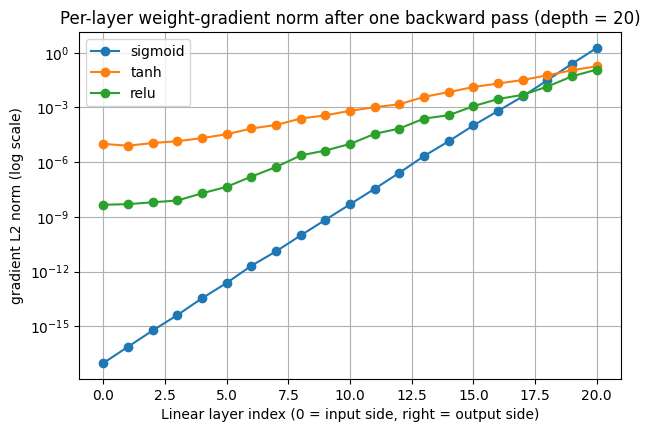

In [9]:
# Build a deep stack of Linear + activation, do ONE backward pass, and collect
# the gradient L2-norm of each Linear layer's weight. Tiny and fast on CPU.
def build_deep_net(depth, width=32, act="sigmoid"):
    acts = {"sigmoid": nn.Sigmoid, "tanh": nn.Tanh, "relu": nn.ReLU}
    layers = []
    for _ in range(depth):
        layers.append(nn.Linear(width, width))
        layers.append(acts[act]())
    layers.append(nn.Linear(width, 1))       # scalar-ish head so we get one loss
    return nn.Sequential(*layers).to(device)

def per_layer_grad_norms(depth=20, act="sigmoid", width=32, batch=64):
    torch.manual_seed(0)                      # same init and data across activations
    net = build_deep_net(depth, width, act)
    x = torch.randn(batch, width, device=device)
    target = torch.randn(batch, 1, device=device)
    loss = F.mse_loss(net(x), target)
    net.zero_grad()
    loss.backward()
    return [m.weight.grad.norm().item() for m in net if isinstance(m, nn.Linear)]

# Static comparison at a fixed depth: sigmoid vs tanh vs relu.
depth0 = 20
plt.figure()
for act in ["sigmoid", "tanh", "relu"]:
    norms = per_layer_grad_norms(depth0, act)
    plt.plot(range(len(norms)), np.maximum(norms, 1e-30), marker="o", label=act)
plt.yscale("log")
plt.title("Per-layer weight-gradient norm after one backward pass (depth = %d)" % depth0)
plt.xlabel("Linear layer index (0 = input side, right = output side)")
plt.ylabel("gradient L2 norm (log scale)")
plt.legend()
plt.show()

### Widget: depth vs activation

Increase the depth and switch the activation. With **sigmoid** (and, less
severely, **tanh**) the left-most bars (near the input) drop by many orders of
magnitude as depth grows: that is the vanishing gradient. **ReLU's**
non-saturating positive region keeps the gradient far healthier all the way to
the input side.

In [10]:
# WIDGET 3: depth slider + activation dropdown -> per-layer gradient bar chart.
def vanishing_demo(depth=15, act="sigmoid"):
    norms = per_layer_grad_norms(depth, act)
    plt.figure()
    plt.bar(range(len(norms)), np.maximum(norms, 1e-30), color="steelblue")
    plt.yscale("log")
    plt.title("Vanishing-gradient check: %s, depth = %d" % (act, depth))
    plt.xlabel("Linear layer index (0 = input side)")
    plt.ylabel("gradient L2 norm (log scale)")
    plt.show()

interact(vanishing_demo,
         depth=IntSlider(min=5, max=30, step=1, value=15),
         act=Dropdown(options=["sigmoid", "tanh", "relu"], value="sigmoid"));

interactive(children=(IntSlider(value=15, description='depth', max=30, min=5), Dropdown(description='act', opt…

## 4. The Dying ReLU problem

ReLU's gradient is exactly $0$ for $x<0$. If a unit's pre-activation is negative
for *every* input in the batch, then its output is always $0$ **and** its gradient
is always $0$, so its incoming weights never update. It becomes a permanently
**"dead" neuron**. A strongly negative bias (which a too-large learning-rate step
can produce) pushes many units into exactly this state.

Fixes from the slides:

- Initialize the bias to a small **positive** value.
- Use **Leaky ReLU** $\max(\alpha x, x)$ or **ELU**: both keep a non-zero slope for
  $x<0$, so a non-firing unit still receives a gradient and can recover.

We take a layer of units, push their biases negative, and count the **dead-unit
fraction** (units whose pre-activation is negative for the whole batch). Then we
switch on a Leaky slope and watch that fraction fall.

In [11]:
# A unit is "dead" (for ReLU) if its pre-activation is <= 0 for the WHOLE batch.
# With a Leaky/ELU slope alpha > 0, even a non-firing unit has gradient alpha != 0,
# so it is never truly dead.
def dead_stats(neg_bias=3.0, alpha=0.0, n_units=300, d_in=20, n_samples=256):
    torch.manual_seed(0)
    W = torch.randn(n_units, d_in, device=device) / (d_in ** 0.5)   # ~unit-variance pre-acts
    b = -neg_bias + 0.5 * torch.randn(n_units, device=device)       # push biases negative
    X = torch.randn(n_samples, d_in, device=device)
    pre = X @ W.t() + b                        # (n_samples, n_units) pre-activations
    fire_rate = (pre > 0).float().mean(dim=0)  # fraction of the batch each unit fires on
    dead_relu = (fire_rate == 0).float().mean().item()
    dead_effective = dead_relu if alpha == 0 else 0.0
    return fire_rate.cpu().numpy(), dead_relu, dead_effective

fr, dead_relu, _ = dead_stats(neg_bias=3.0, alpha=0.0)
print("Negative bias offset 3.0, plain ReLU:")
print("  dead-unit fraction = %.1f%%  (these units never fire, so their gradient is always 0)" %
      (100 * dead_relu))
_, _, dead_leaky = dead_stats(neg_bias=3.0, alpha=0.1)
print("Same layer with Leaky ReLU (alpha=0.1):")
print("  dead-unit fraction = %.1f%%  (non-zero negative slope revives every unit)" %
      (100 * dead_leaky))

Negative bias offset 3.0, plain ReLU:
  dead-unit fraction = 58.0%  (these units never fire, so their gradient is always 0)
Same layer with Leaky ReLU (alpha=0.1):
  dead-unit fraction = 0.0%  (non-zero negative slope revives every unit)


### Widget: kill units, then revive them

Raise `neg_bias` to push more units below zero for the whole batch: the left
histogram piles up at a firing rate of $0$ and the dead-unit fraction climbs. Now
raise the Leaky slope `alpha` above $0$: because the negative side then has slope
$\alpha \neq 0$, no unit has a zero gradient anymore, so the dead fraction drops
to $0$ (the units can learn their way back). ELU behaves the same way, since its
negative-side derivative $\alpha e^{x}$ is also non-zero.

In [12]:
# WIDGET 4: neg_bias slider (kills units) + Leaky alpha slider (revives them).
def dying_relu_demo(neg_bias=3.0, alpha=0.0):
    fr, dead_relu, dead_eff = dead_stats(neg_bias, alpha)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
    ax1.hist(fr, bins=20, range=(0, 1), color="steelblue")
    ax1.set_title("Per-unit firing rate (plain ReLU dead = %.1f%%)" % (100 * dead_relu))
    ax1.set_xlabel("fraction of batch that activates the unit")
    ax1.set_ylabel("number of units")
    ax2.bar(["plain ReLU", "Leaky (a=%.2f)" % alpha], [dead_relu, dead_eff],
            color=["salmon", "seagreen"])
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("fraction of units with zero gradient (dead)")
    ax2.set_title("Dead units: ReLU vs Leaky / ELU")
    plt.tight_layout()
    plt.show()

interact(dying_relu_demo,
         neg_bias=FloatSlider(min=0.0, max=6.0, step=0.25, value=3.0),
         alpha=FloatSlider(min=0.0, max=0.3, step=0.01, value=0.0));

interactive(children=(FloatSlider(value=3.0, description='neg_bias', max=6.0, step=0.25), FloatSlider(value=0.…

## 5. The zero-centered issue (brief)

From the slides, for a neuron whose pre-activation is $a = \sum_i w_i h_i$ feeding
an output $y$, the gradient of each incoming weight is
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial y}\,\frac{\partial y}{\partial a}\,h_i = \delta\, h_i,$$
where the factor $\delta = \frac{\partial L}{\partial y}\frac{\partial y}{\partial a}$
is **shared** by all incoming weights. If the inputs $h_i$ are sigmoid outputs
they are **all positive**, so every $\partial L/\partial w_i$ takes the sign of
$\delta$: all incoming weights want to move the same way at once. With only "all
up" or "all down" moves available, the update path has to **zig-zag** toward the
optimum. **Tanh** outputs are zero-centered (mixed signs), which unblocks the
other update directions.

The plot below shows the incoming-weight gradients for one neuron (left), and the
directions the weight vector is allowed to move in the 2-weight case (right).

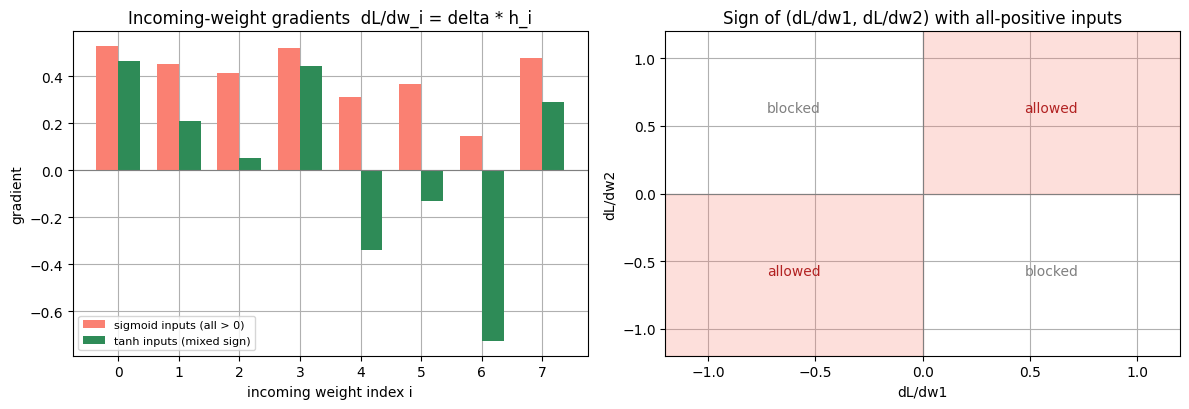

sigmoid-input gradient signs: [1 1 1 1 1 1 1 1]  (all the same)
tanh-input gradient signs:    [ 1  1  1  1 -1 -1 -1  1]  (mixed)


In [13]:
# All-positive (sigmoid) inputs force every incoming-weight gradient to share the
# sign of the shared upstream factor delta. Tanh inputs are zero-centered (mixed).
torch.manual_seed(1)
delta = 0.8                          # a single shared upstream scalar for this neuron
z = torch.randn(8)                   # raw pre-activations from the previous layer
h_sig = sigmoid(z)                   # all positive  -> not zero-centered
h_tanh = tanh(z)                     # mixed sign     -> zero-centered
g_sig = (delta * h_sig).numpy()      # incoming-weight gradients with sigmoid inputs
g_tanh = (delta * h_tanh).numpy()    # incoming-weight gradients with tanh inputs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
idx = np.arange(8)
ax1.bar(idx - 0.18, g_sig, width=0.36, label="sigmoid inputs (all > 0)", color="salmon")
ax1.bar(idx + 0.18, g_tanh, width=0.36, label="tanh inputs (mixed sign)", color="seagreen")
ax1.axhline(0, color="gray", lw=0.8)
ax1.set_title("Incoming-weight gradients  dL/dw_i = delta * h_i")
ax1.set_xlabel("incoming weight index i"); ax1.set_ylabel("gradient")
ax1.legend(fontsize=8)

# 2-weight picture: with h1, h2 > 0 the gradient (delta*h1, delta*h2) can only sit
# in quadrant I (both +) or III (both -). Shade those "allowed" quadrants.
ax2.axhline(0, color="gray", lw=0.8); ax2.axvline(0, color="gray", lw=0.8)
ax2.fill_between([0, 1.2], 0, 1.2, color="salmon", alpha=0.25)
ax2.fill_between([-1.2, 0], -1.2, 0, color="salmon", alpha=0.25)
ax2.text(0.6, 0.6, "allowed", ha="center", color="firebrick")
ax2.text(-0.6, -0.6, "allowed", ha="center", color="firebrick")
ax2.text(-0.6, 0.6, "blocked", ha="center", color="gray")
ax2.text(0.6, -0.6, "blocked", ha="center", color="gray")
ax2.set_xlim(-1.2, 1.2); ax2.set_ylim(-1.2, 1.2)
ax2.set_title("Sign of (dL/dw1, dL/dw2) with all-positive inputs")
ax2.set_xlabel("dL/dw1"); ax2.set_ylabel("dL/dw2")
plt.tight_layout()
plt.show()

print("sigmoid-input gradient signs:", np.sign(g_sig).astype(int), " (all the same)")
print("tanh-input gradient signs:   ", np.sign(g_tanh).astype(int), " (mixed)")

## Key takeaways and which activation to choose

- Good activations are **continuous, differentiable, non-decreasing, and cheap**.
- **Sigmoid:** saturates (tiny gradients far from $0$), is **not zero-centered**
  (zig-zag updates), and uses an expensive `exp`. Rarely used in vanilla nets
  today; mainly kept for **gating**.
- **Tanh:** zero-centered (better than sigmoid), but **still saturates** and still
  uses `exp`.
- **ReLU:** non-saturating for positive inputs, converges much faster (about
  **6x** in AlexNet), and is cheap. The **default** choice today, but watch for
  dead units.
- **Leaky ReLU / ELU / Maxout:** variants that avoid dead units by keeping a
  non-zero negative-side slope.

**Practical recipe (straight from the slides):**

1. Use **ReLU** by default; be careful with learning rates and monitor the
   fraction of dead units.
2. Try **Leaky ReLU, ELU, Maxout**.
3. Try **tanh**, but expect worse performance.
4. Use **sigmoid** only when a gating is required.
5. In general it is good for an activation to stay in its (near) **linear region**
   for most of training.

## Exercises

in section 3, switch the deep net to `tanh` and compare its
per-layer gradient decay against `sigmoid` and `relu`. Then, in section 4, replace
the negative bias with a small **positive** bias and confirm the dead-unit
fraction drops toward $0$. Bonus: add **GELU** or **Maxout** to the section 1 zoo,
implemented from scratch, and verify it against PyTorch.